# Análise aprofundada do LEN-small

**Integrantes:** Gabriel de Santana Santos - 10420595 - 10420595@mackenzista.com.br; Gabriel Erick Mendes - 10420391 - 10420391@mackenzista.com.br; Matheus Teles Magalhães - 10427410 - 10427410@mackenzista.com.br.

**Conteúdo:** análise de integridade, comparação entre classes, geração de estados parciais e avaliação de características estruturais e temporais.

**Histórico:** 21/09/2026 | Gabriel Erick Mendes | Criação da análise aprofundada; 24/09/2026 | Grupo | Revisão, correção das interpretações e preparação para a entrega da disciplina.

## Objetivo

Analisar a integridade dos arquivos, comparar campanhas e não campanhas e
descrever como os grafos crescem quando apenas o início da atividade está
disponível.

Nenhum modelo é treinado nesta etapa. A análise identifica diferenças entre as
classes, limitações do conjunto de dados e medidas que poderão ser testadas nos
modelos de classificação.


## Definições

- **Campanha:** tópico identificado pelo LEN como campanha coordenada.
- **Não campanha:** tópico selecionado como provavelmente orgânico.
- **Estado parcial:** grafo formado apenas pelas primeiras interações de um
  grafo completo.
- **Fração do tempo:** parte da duração entre a primeira e a última aresta.
- **Fração das arestas:** parte do número final de arestas, em ordem temporal.

Nos gráficos, azul representa campanhas e laranja representa não campanhas. As
duas formas de parcialidade aparecem em gráficos separados.


## 1. Tabelas

A tabela `len_small_summary.csv` possui uma linha para cada grafo completo. A
tabela `partial_graph_features.csv` possui uma linha para cada estado parcial de
cada grafo.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SUMMARY = ROOT / "dados" / "processados" / "len_small_summary.csv"
FEATURES = ROOT / "dados" / "processados" / "partial_graph_features.csv"
DUPLICATE = "#SesimiziDuyanVarMi___2023-03-23_campaign_fulldata.json"

CLASS_NAMES = {"campaign": "Campanha", "noncampaign": "Não campanha"}
COLORS = {"campaign": "#277DA1", "noncampaign": "#F8961E"}

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
graphs = pd.read_csv(SUMMARY)
graphs = graphs.loc[graphs["file"] != DUPLICATE].copy()
snapshots = pd.read_csv(FEATURES)

resumo_amostra = pd.DataFrame({
    "Quantidade": [
        len(graphs),
        (graphs["label"] == "campaign").sum(),
        (graphs["label"] == "noncampaign").sum(),
        len(snapshots),
    ]
}, index=[
    "Grafos únicos locais",
    "Campanhas",
    "Não campanhas",
    "Estados parciais",
])
resumo_amostra

,Quantidade
Grafos únicos locais,103
Campanhas,52
Não campanhas,51
Estados parciais,2060


### Conclusão

Depois de retirar uma duplicata, o pacote local possui 103 grafos. O artigo
descreve 100. Portanto, ainda precisamos identificar quais três arquivos não
fazem parte da versão usada no artigo.

Os 2.060 estados parciais correspondem a:

```text
103 grafos × 2 formas de parcialidade × 10 frações
```


## 2. Integridade dos arquivos

Foram verificados timestamps ausentes, usuários duplicados, arestas ligadas a
usuários inexistentes e tamanhos acima dos limites publicados para o LEN-small.

A tabela apresenta somente os arquivos que falharam em pelo menos uma dessas
verificações. Uma linha sinaliza que o arquivo precisa ser investigado; ela não
confirma, sozinha, que o arquivo está errado.


In [3]:
problem = (
    (graphs["duplicate_node_ids"] > 0)
    | (graphs["missing_edge_endpoints"] > 0)
    | (graphs["timestamp_coverage"] < 1)
    | (graphs["nodes"] > 8355)
    | (graphs["edges"] > 10608)
)

problemas = graphs.loc[
    problem,
    ["file", "label", "nodes", "edges", "timestamp_coverage"],
].rename(columns={
    "file": "Arquivo",
    "label": "Classe",
    "nodes": "Usuários",
    "edges": "Arestas",
    "timestamp_coverage": "Cobertura de timestamps",
})
problemas["Classe"] = problemas["Classe"].map(CLASS_NAMES)
problemas

,Arquivo,Classe,Usuários,Arestas,Cobertura de timestamps
30,#TekeTek_noncampaign_fulldata.json,Não campanha,7739,10682,1.0


### Conclusão

Um arquivo ultrapassa por pouco o máximo de arestas informado no artigo. Isso
reforça a suspeita de que o pacote local e a amostra descrita no artigo não são
exatamente a mesma versão. Os demais testes básicos de integridade não
encontraram problemas.


## 3. Tamanho e estrutura das classes

A comparação utiliza a mediana, que representa um valor típico sem dar peso
excessivo aos maiores grafos.

Diferenças grandes entre as classes podem ser aprendidas pelo modelo mesmo
quando resultam apenas da forma como o dataset foi construído. Por isso, tamanho
e estrutura são analisados separadamente.


In [4]:
metricas = {
    "nodes": "Usuários",
    "edges": "Arestas",
    "interaction_count_sum": "Interações agrupadas",
    "duration_hours": "Duração (horas)",
    "density": "Densidade",
    "mean_total_degree": "Grau médio",
    "reciprocity": "Reciprocidade",
    "weak_components": "Componentes",
    "largest_weak_component_fraction": "Parcela no maior componente",
}

comparacao = graphs.groupby("label")[list(metricas)].median().T
comparacao.columns = [CLASS_NAMES[column] for column in comparacao.columns]
comparacao.index = [metricas[index] for index in comparacao.index]
comparacao.round(4)

,Campanha,Não campanha
Usuários,506.0000,3227.0000
Arestas,1078.0000,3769.0000
Interações agrupadas,1647.0000,4835.0000
Duração (horas),22.6026,23.9419
Densidade,0.0042,0.0003
Grau médio,3.5730,2.3854
Reciprocidade,0.0311,0.0051
Componentes,15.0000,142.0000
Parcela no maior componente,0.6934,0.7252


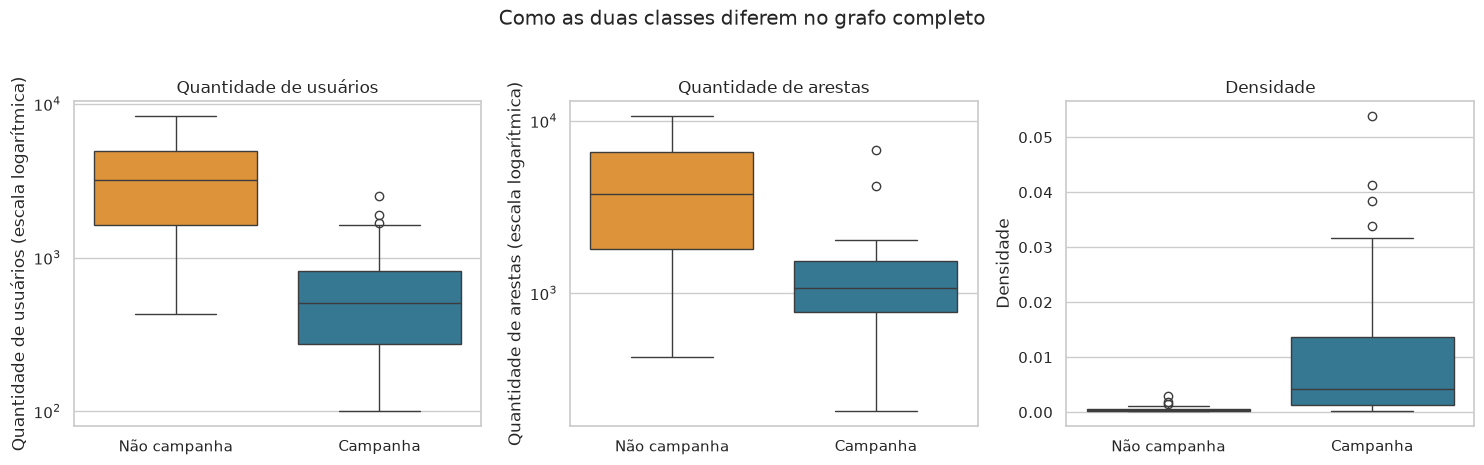

In [5]:
plot_data = graphs.assign(Classe=graphs["label"].map(CLASS_NAMES))
palette = {CLASS_NAMES[key]: value for key, value in COLORS.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
configuracoes = [
    ("nodes", "Quantidade de usuários", True),
    ("edges", "Quantidade de arestas", True),
    ("density", "Densidade", False),
]

for (column, title, log_scale), axis in zip(configuracoes, axes):
    sns.boxplot(
        data=plot_data,
        x="Classe",
        y=column,
        hue="Classe",
        palette=palette,
        legend=False,
        ax=axis,
    )
    if log_scale:
        axis.set_yscale("log")
        axis.set_ylabel(f"{title} (escala logarítmica)")
    else:
        axis.set_ylabel(title)
    axis.set_xlabel("")
    axis.set_title(title)

fig.suptitle("Como as duas classes diferem no grafo completo", y=1.03)
plt.tight_layout()

### Conclusão

Campanhas possuem menos usuários e menos arestas do que não campanhas. Elas
também parecem mais densas, mas a densidade é afetada pelo tamanho do grafo e
não pode ser interpretada isoladamente.

Em 93,6% das comparações entre uma campanha e uma não campanha escolhidas ao
acaso, a campanha possui menos usuários. O tamanho pode, portanto, funcionar
como um atalho para o modelo.

O eixo logarítmico permite mostrar grafos pequenos e grandes no mesmo painel ao
comprimir os valores mais altos.


## 4. Variáveis relacionadas

O gráfico abaixo mostra correlações. Valores próximos de 1 indicam que duas
medidas normalmente crescem juntas. Valores próximos de -1 indicam que uma
normalmente diminui quando a outra cresce.

**Indícios:** valores próximos de 1 ou -1 indicam medidas muito
relacionadas, que podem repetir a mesma informação.

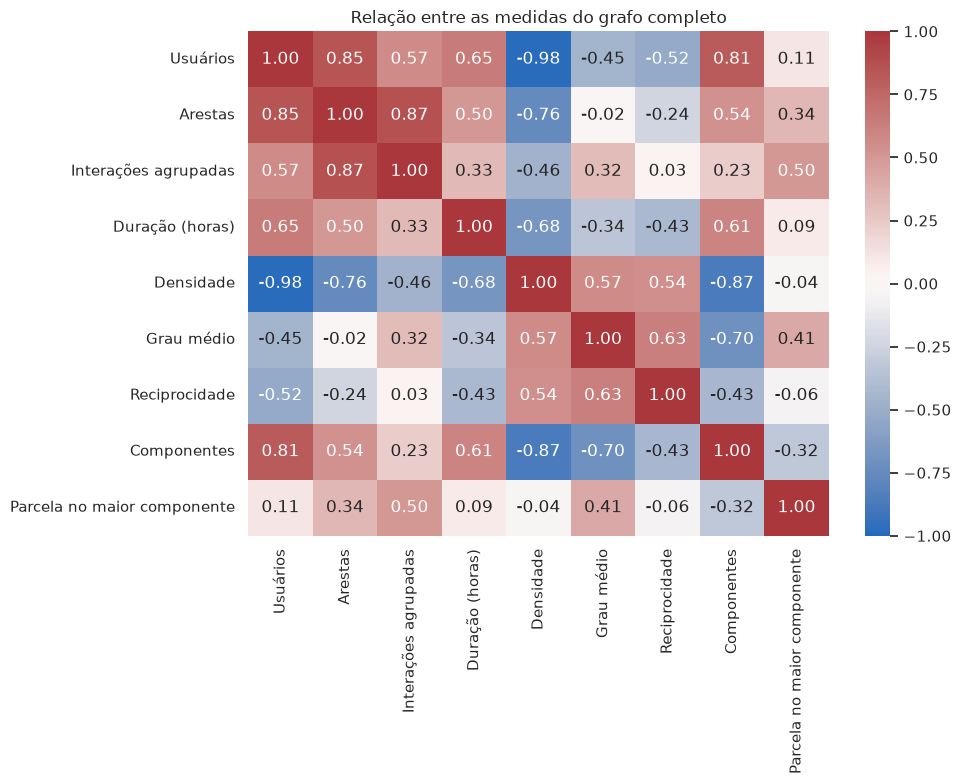

In [6]:
correlation = graphs[list(metricas)].corr(method="spearman")
correlation.index = [metricas[index] for index in correlation.index]
correlation.columns = [metricas[column] for column in correlation.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
)
plt.title("Relação entre as medidas do grafo completo")
plt.tight_layout()

### Conclusão parcial

Número de usuários e densidade possuem correlação de -0,98. Isso acontece porque
a fórmula da densidade divide as arestas pelo número de relações possíveis, que
cresce rapidamente em grafos grandes.

Usuários e arestas possuem correlação positiva de 0,85, enquanto a densidade
apresenta correlação negativa com usuários (-0,98) e arestas (-0,76). Isso não
significa que aumentar a densidade reduz diretamente o número de arestas. A
associação ocorre porque o denominador da densidade cresce aproximadamente com
o quadrado do número de usuários, enquanto as arestas crescem mais lentamente.

Densidade maior não pode ser interpretada sozinha como sinal de
coordenação. Ela pode ser apenas consequência de as campanhas serem menores.

## 5. Conferir a tabela de estados parciais

Nesta análise, **fração** pode ter dois significados:

- no modo `time`, 30% significa que passaram 30% da duração total do grafo;
- no modo `events`, 30% significa que observamos as primeiras 30% das arestas.

A tabela abaixo apenas confirma que todas as combinações esperadas foram
criadas e que não existem linhas repetidas.

In [7]:
validacao = pd.DataFrame({
    "Resultado": [
        len(snapshots),
        snapshots["file"].nunique(),
        snapshots["partiality_mode"].nunique(),
        snapshots["fraction"].nunique(),
        snapshots.duplicated(["file", "partiality_mode", "fraction"]).sum(),
    ]
}, index=[
    "Estados parciais criados",
    "Grafos representados",
    "Formas de parcialidade",
    "Frações por forma",
    "Linhas repetidas",
])
validacao

,Resultado
Estados parciais criados,2060
Grafos representados,103
Formas de parcialidade,2
Frações por forma,10
Linhas repetidas,0


## 6. Crescimento dos grafos

As mesmas três relações são apresentadas duas vezes. A primeira sequência usa
as quantidades observadas. A segunda divide cada quantidade pelo total final do
próprio grafo.

O gráfico de arestas por fração das arestas não aparece em nenhuma sequência,
pois seus dois eixos representam a mesma quantidade e formariam a diagonal
`y = x`.

### Contagens absolutas

Cada linha representa a mediana das quantidades observadas nos grafos da mesma
classe. Da esquerda para a direita:

1. **Usuários por tempo:** quantidade de usuários já observados em cada fração
   da duração total.
2. **Arestas por tempo:** quantidade de arestas já observadas em cada fração da
   duração total.
3. **Usuários por arestas:** quantidade de usuários já observados em cada fração
   do total de arestas.


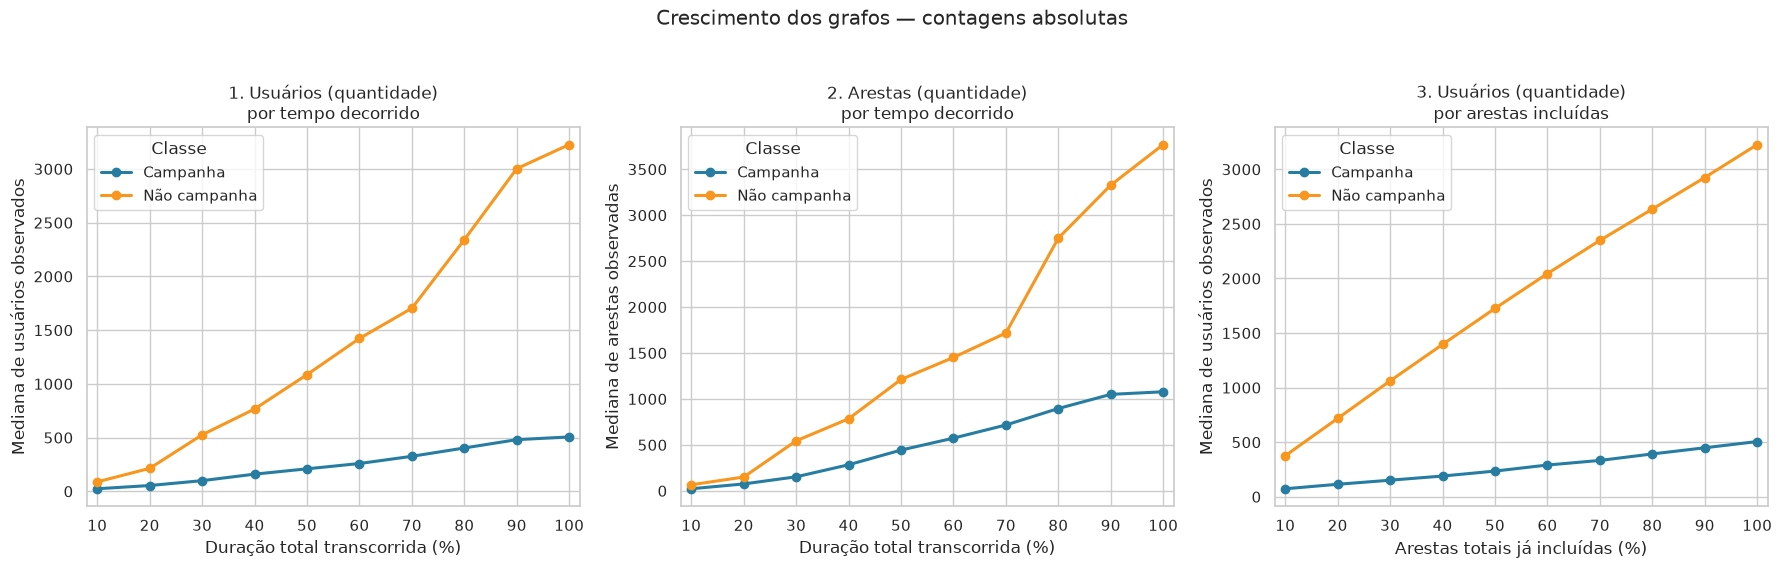

In [8]:
absolute_plot_specs = [
    {
        "mode": "time",
        "metric": "nodes",
        "title": "1. Usuários (quantidade)\npor tempo decorrido",
        "xlabel": "Duração total transcorrida (%)",
        "ylabel": "Mediana de usuários observados",
    },
    {
        "mode": "time",
        "metric": "edges",
        "title": "2. Arestas (quantidade)\npor tempo decorrido",
        "xlabel": "Duração total transcorrida (%)",
        "ylabel": "Mediana de arestas observadas",
    },
    {
        "mode": "events",
        "metric": "nodes",
        "title": "3. Usuários (quantidade)\npor arestas incluídas",
        "xlabel": "Arestas totais já incluídas (%)",
        "ylabel": "Mediana de usuários observados",
    },
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for axis, spec in zip(axes, absolute_plot_specs):
    subset = snapshots.loc[snapshots["partiality_mode"] == spec["mode"]]
    medians = (
        subset.groupby(["label", "fraction"], as_index=False)[spec["metric"]]
        .median()
    )

    for label in ["campaign", "noncampaign"]:
        line = medians.loc[medians["label"] == label]
        axis.plot(
            line["fraction"] * 100,
            line[spec["metric"]],
            marker="o",
            linewidth=2.2,
            color=COLORS[label],
            label=CLASS_NAMES[label],
        )

    axis.set_title(spec["title"])
    axis.set_xlabel(spec["xlabel"])
    axis.set_ylabel(spec["ylabel"])
    axis.set_xlim(8, 102)
    axis.set_xticks(range(10, 101, 10))
    axis.legend(title="Classe")

fig.suptitle("Crescimento dos grafos — contagens absolutas", y=1.03)
plt.tight_layout()


### Contagens normalizadas

A normalização é calculada separadamente em cada grafo:

- **usuários observados (%):** número de usuários já observados dividido pelo
  número total de usuários do mesmo grafo;
- **arestas observadas (%):** número de arestas já observadas dividido pelo
  número total de arestas do mesmo grafo.

Assim, 50% significa que metade da quantidade final daquele grafo já foi
observada, independentemente de seu tamanho. As linhas apresentam a mediana
dessas proporções em cada classe. Da esquerda para a direita:

1. **Usuários por tempo:** porcentagem dos usuários finais já observada em cada
   fração da duração.
2. **Arestas por tempo:** porcentagem das arestas finais já observada em cada
   fração da duração.
3. **Usuários por arestas:** porcentagem dos usuários finais já observada em
   cada fração do total de arestas.


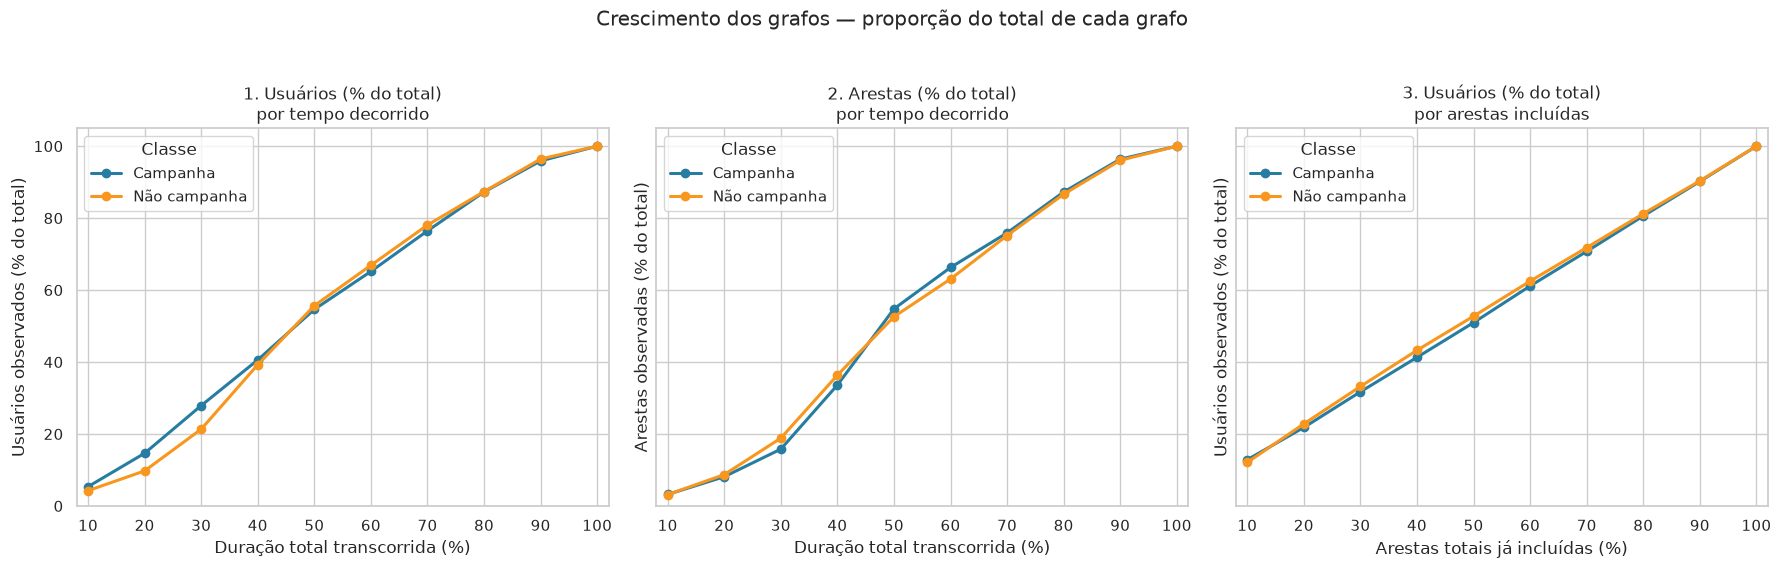

In [9]:
totals = (
    snapshots.loc[
        snapshots["fraction"].eq(1),
        ["file", "partiality_mode", "nodes", "edges"],
    ]
    .rename(columns={"nodes": "total_nodes", "edges": "total_edges"})
)

normalized_snapshots = snapshots.merge(
    totals,
    on=["file", "partiality_mode"],
    how="left",
    validate="many_to_one",
)
normalized_snapshots["users_observed_pct"] = (
    100 * normalized_snapshots["nodes"] / normalized_snapshots["total_nodes"]
)
normalized_snapshots["edges_observed_pct"] = (
    100 * normalized_snapshots["edges"] / normalized_snapshots["total_edges"]
)

normalized_plot_specs = [
    {
        "mode": "time",
        "metric": "users_observed_pct",
        "title": "1. Usuários (% do total)\npor tempo decorrido",
        "xlabel": "Duração total transcorrida (%)",
        "ylabel": "Usuários observados (% do total)",
    },
    {
        "mode": "time",
        "metric": "edges_observed_pct",
        "title": "2. Arestas (% do total)\npor tempo decorrido",
        "xlabel": "Duração total transcorrida (%)",
        "ylabel": "Arestas observadas (% do total)",
    },
    {
        "mode": "events",
        "metric": "users_observed_pct",
        "title": "3. Usuários (% do total)\npor arestas incluídas",
        "xlabel": "Arestas totais já incluídas (%)",
        "ylabel": "Usuários observados (% do total)",
    },
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for axis, spec in zip(axes, normalized_plot_specs):
    subset = normalized_snapshots.loc[
        normalized_snapshots["partiality_mode"] == spec["mode"]
    ]
    medians = (
        subset.groupby(["label", "fraction"], as_index=False)[spec["metric"]]
        .median()
    )

    for label in ["campaign", "noncampaign"]:
        line = medians.loc[medians["label"] == label]
        axis.plot(
            line["fraction"] * 100,
            line[spec["metric"]],
            marker="o",
            linewidth=2.2,
            color=COLORS[label],
            label=CLASS_NAMES[label],
        )

    axis.set_title(spec["title"])
    axis.set_xlabel(spec["xlabel"])
    axis.set_ylabel(spec["ylabel"])
    axis.set_xlim(8, 102)
    axis.set_ylim(0, 105)
    axis.set_xticks(range(10, 101, 10))
    axis.set_yticks(range(0, 101, 20))
    axis.legend(title="Classe")

fig.suptitle("Crescimento dos grafos — proporção do total de cada grafo", y=1.03)
plt.tight_layout()


### Conclusão

Nas contagens absolutas, não campanhas possuem muito mais usuários e arestas em
todas as frações. Em 10% da duração, a campanha mediana possui 24 usuários e a
não campanha mediana possui 88. Em 10% das arestas, esses valores são 73,5 e
376 usuários. Esses gráficos mostram a quantidade efetivamente disponível em
cada momento.

Depois da normalização, as curvas das duas classes ficam próximas. A separação
observada nas contagens absolutas é explicada principalmente pelo tamanho final
dos grafos, e não por ritmos de crescimento muito diferentes.

A maior diferença proporcional aparece no gráfico de usuários por tempo. Em
30% da duração, a campanha mediana já apresentou 27,9% de seus usuários e a não
campanha mediana apresentou 21,3%. A diferença diminui nas frações seguintes.
Nos demais gráficos normalizados, as curvas permanecem muito próximas.

As duas sequências respondem a perguntas diferentes. As contagens absolutas
mostram quanto do grafo está disponível para o modelo. As proporções mostram o
quanto cada grafo avançou em relação ao próprio tamanho final.


## 7. Medidas estruturais e temporais

Os gráficos utilizam a fração das arestas para comparar medidas que não são
contagens simples.

### Definições

- **Reciprocidade:** proporção de relações que aparecem nos dois sentidos.
- **Parcela no maior componente:** proporção de usuários que pertence ao maior
  grupo conectado da rede.
- **Modularidade:** intensidade da divisão da rede em grupos com mais conexões
  internas do que externas.
- **Regularidade temporal:** distribuição das arestas ao longo do tempo. Valores
  diferentes indicam maior concentração ou maior dispersão das interações.

Uma diferença que aparece cedo e permanece nas frações seguintes é mais útil
para a detecção precoce do que uma diferença isolada em uma única fração.


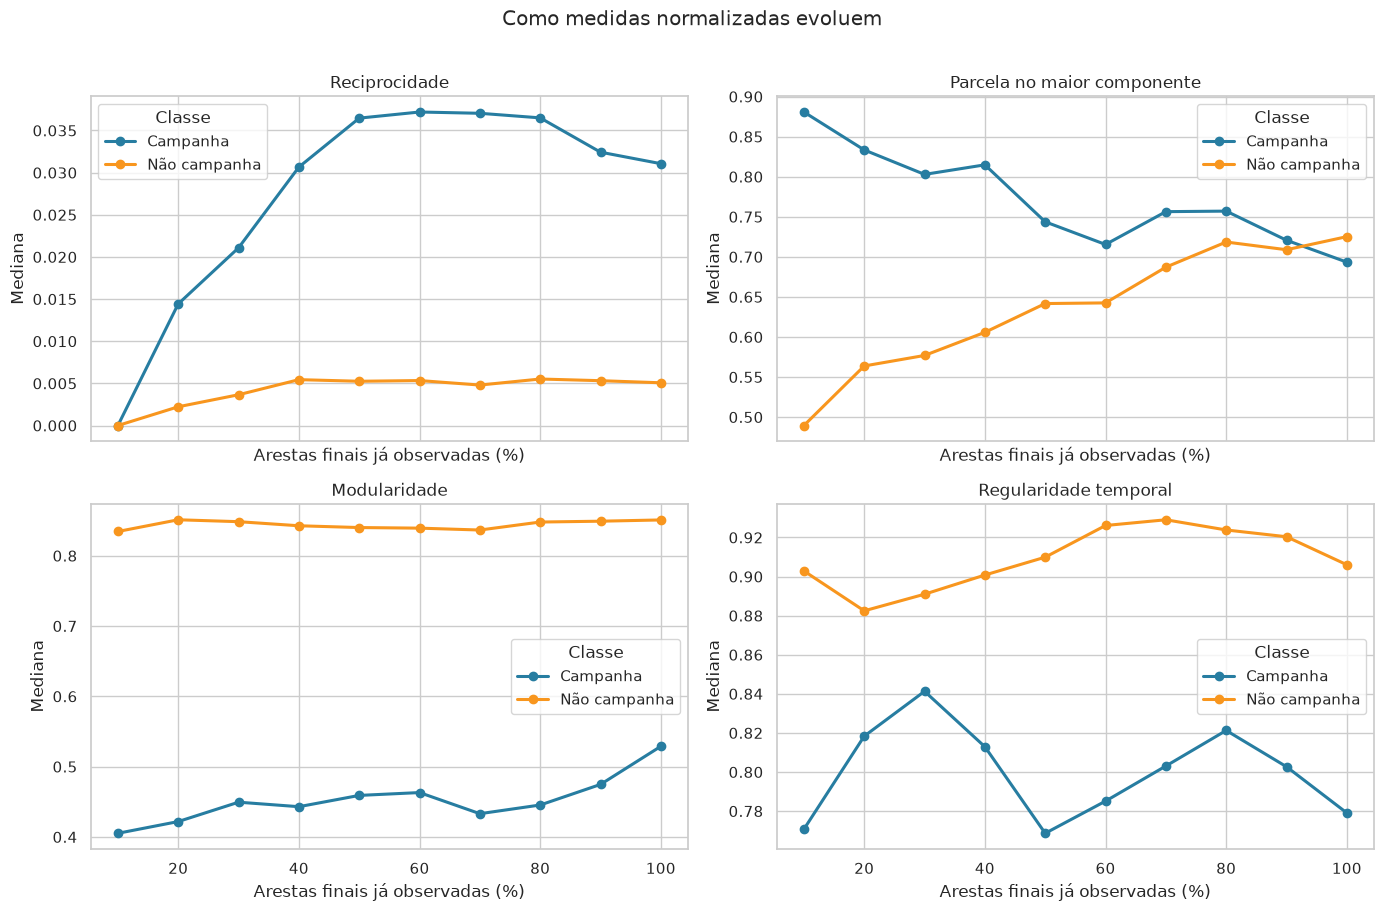

In [10]:
metric_titles = {
    "reciprocity": "Reciprocidade",
    "largest_weak_component_fraction": "Parcela no maior componente",
    "modularity": "Modularidade",
    "temporal_entropy": "Regularidade temporal",
}

event_snapshots = snapshots.loc[snapshots["partiality_mode"] == "events"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for (column, title), axis in zip(metric_titles.items(), axes.flat):
    medians = event_snapshots.groupby(["label", "fraction"], as_index=False)[column].median()
    for label in ["campaign", "noncampaign"]:
        line = medians.loc[medians["label"] == label]
        axis.plot(
            line["fraction"] * 100,
            line[column],
            marker="o",
            linewidth=2.2,
            color=COLORS[label],
            label=CLASS_NAMES[label],
        )
    axis.set_title(title)
    axis.set_xlabel("Arestas finais já observadas (%)")
    axis.set_ylabel("Mediana")
    axis.legend(title="Classe")

fig.suptitle("Como medidas normalizadas evoluem", y=1.01)
plt.tight_layout()

### Conclusão

A modularidade apresenta a separação visual mais forte. Não campanhas parecem
mais divididas em grupos. A regularidade temporal também diferencia as classes
em várias frações.

Essas diferenças ainda podem ser influenciadas pelo tamanho dos grafos. O
treinamento deverá verificar se modularidade e regularidade temporal acrescentam
informação depois que o tamanho for controlado.


## 8. Valores ausentes

### Definição

Valor ausente indica que uma medida não pôde ser calculada. Isso é diferente de
zero. A tabela registra quantos estados foram afetados e o motivo de cada
ausência.


In [11]:
numeric = snapshots.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
interval_columns = {
    "interevent_seconds_mean": "Intervalo médio",
    "interevent_seconds_median": "Intervalo mediano",
    "interevent_seconds_p90": "Percentil 90 do intervalo",
    "interevent_seconds_max": "Maior intervalo",
}

ausencias = []
for column, name in interval_columns.items():
    count = int(numeric[column].isna().sum())
    if count:
        ausencias.append({
            "Medida": name,
            "Estados sem valor": count,
            "Percentual": count / len(snapshots),
            "Motivo": "O estado possui somente uma aresta; não existe intervalo entre eventos.",
        })

tabela_ausencias = pd.DataFrame(ausencias)
tabela_ausencias.style.format({"Percentual": "{:.2%}"})

,Medida,Estados sem valor,Percentual,Motivo
0,Intervalo médio,26,1.26%,O estado possui somente uma aresta; não existe intervalo entre eventos.
1,Intervalo mediano,26,1.26%,O estado possui somente uma aresta; não existe intervalo entre eventos.
2,Percentil 90 do intervalo,26,1.26%,O estado possui somente uma aresta; não existe intervalo entre eventos.
3,Maior intervalo,26,1.26%,O estado possui somente uma aresta; não existe intervalo entre eventos.


### Conclusão

Existem 26 estados com apenas uma aresta. Neles, não há dois eventos para medir
o intervalo entre um e outro. Por isso, quatro medidas de intervalo ficam sem
valor.

Isso é esperado e não indica perda de dados. No treinamento, esses valores serão
tratados por uma regra calculada somente com os dados de treino.


## Conclusão

O LEN possui informação temporal suficiente para criar grafos parciais. O código
gerou os 2.060 estados esperados e as duas formas de parcialidade chegam ao mesmo
grafo em 100%.

Ao mesmo tempo, a análise revelou um risco importante: campanhas são muito
menores do que não campanhas. Um modelo pode alcançar bom desempenho usando
apenas essa diferença. Portanto, o primeiro resultado de classificação deverá
ser tratado como ponto de partida, não como prova de que encontramos sinais de
coordenação.

As duas formas de parcialidade devem continuar separadas:

- fração do tempo representa quanto da duração já passou;
- fração das arestas representa quanto da estrutura final já foi observado.

Elas produzem grafos iniciais diferentes porque a atividade não ocorre em ritmo
constante. Essa comparação será parte central do trabalho.

Antes do treinamento, precisamos:

1. identificar oficialmente os 100 grafos do LEN-small;
2. congelar a lista de arquivos;
3. separar os grafos por tópico em treino, validação e teste;
4. criar um modelo que usa somente tamanho;
5. comparar esse modelo com conjuntos de medidas estruturais e temporais;
6. descobrir em qual fração as diferenças se tornam estáveis;
7. verificar se medidas como modularidade e regularidade temporal continuam
   úteis quando o tamanho é controlado.

O resultado desejado não é apenas uma métrica alta. Queremos demonstrar se há
informação útil nas fases iniciais da rede e explicar de onde essa informação
vem.
